In [ ]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=True)

In [ ]:
# Small regression dataset
df = pd.DataFrame(
    [
        [8, 8, 4],
        [7, 9, 5],
        [6, 10, 6],
        [5, 12, 7]
    ],
    columns=["cgpa", "profile_score", "lpa"]
)

df

,cgpa,profile_score,lpa
0,8,8,4
1,7,9,5
2,6,10,6
3,5,12,7


In [ ]:
# Input features and target
X = df[["cgpa", "profile_score"]].values
y = df[["lpa"]].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X:\n", X)
print("y:\n", y)


X shape: (4, 2)
y shape: (4, 1)
X:
 [[ 8  8]
 [ 7  9]
 [ 6 10]
 [ 5 12]]
y:
 [[4]
 [5]
 [6]
 [7]]


In [ ]:
def initialize_parameters(layer_dims):
    np.random.seed(3)

    parameters = {}
    L = len(layer_dims) - 1

    for l in range(1, L + 1):
        parameters[f"W{l}"] = np.ones(
            (layer_dims[l - 1], layer_dims[l])
        ) * 0.1

        parameters[f"b{l}"] = np.zeros(
            (layer_dims[l], 1)
        )

    return parameters


parameters = initialize_parameters([2, 2, 1])

for key, value in parameters.items():
    print(f"{key}:")
    print(value)
    print()

W1:
[[0.1 0.1]
 [0.1 0.1]]

b1:
[[0.]
 [0.]]

W2:
[[0.1]
 [0.1]]

b2:
[[0.]]



In [ ]:
def linear_forward(A_prev, W, b):
    # W shape: (current_layer, previous_layer)
    # A_prev shape: (previous_layer, number_of_examples)
    return W.T @ A_prev + b


def L_layer_forward(X, parameters):
    A = X
    activations = {"A0": X}

    L = len(parameters) // 2

    for l in range(1, L + 1):
        W = parameters[f"W{l}"]
        b = parameters[f"b{l}"]

        A = linear_forward(A, W, b)
        activations[f"A{l}"] = A

    return A, activations

In [ ]:
# Test one training example
X_single = X[0].reshape(2, 1)
y_single = y[0, 0]

y_hat, activations = L_layer_forward(X_single, parameters)

print("Input X:", X_single.ravel())
print("Actual y:", y_single)
print("Predicted y:", y_hat.ravel())
print("Hidden activation A1:", activations["A1"].ravel())

Input X: [8 8]
Actual y: 4
Predicted y: [0.32]
Hidden activation A1: [1.6 1.6]


In [ ]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


loss = mse_loss(
    np.array([[y_single]]),
    y_hat
)

print("Loss:", loss)

Loss: 13.542399999999997


In [ ]:
def backward_propagation(X, y, y_hat, activations, parameters):
    # ----- Output layer -----
    A1 = activations["A1"]

    # dL/dy_hat
    dZ2 = 2 * (y_hat - y)

    # Since y_hat = W2.T @ A1 + b2
    dW2 = A1 @ dZ2.T
    db2 = dZ2

    # Gradient flowing to hidden layer
    dA1 = parameters["W2"] @ dZ2

    # Hidden layer is linear, so dZ1 = dA1
    dZ1 = dA1

    # Since A1 = W1.T @ X + b1
    dW1 = X @ dZ1.T
    db1 = dZ1

    grads = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return grads

In [ ]:
# Check gradients for one example
X_single = X[0].reshape(2, 1)
y_single = np.array([[y[0, 0]]])

y_hat, activations = L_layer_forward(X_single, parameters)

grads = backward_propagation(
    X_single,
    y_single,
    y_hat,
    activations,
    parameters
)

for key, value in grads.items():
    print(f"{key}:")
    print(value)
    print()


dW1:
[[-5.888 -5.888]
 [-5.888 -5.888]]

db1:
[[-0.736]
 [-0.736]]

dW2:
[[-11.776]
 [-11.776]]

db2:
[[-7.36]]



In [ ]:
def update_parameters(parameters, grads, learning_rate=0.001):
    parameters["W1"] -= learning_rate * grads["dW1"]
    parameters["b1"] -= learning_rate * grads["db1"]
    parameters["W2"] -= learning_rate * grads["dW2"]
    parameters["b2"] -= learning_rate * grads["db2"]

    return parameters

In [ ]:
# One complete training step
parameters = initialize_parameters([2, 2, 1])

X_single = X[0].reshape(2, 1)
y_single = np.array([[y[0, 0]]])

y_hat, activations = L_layer_forward(X_single, parameters)

loss_before = mse_loss(y_single, y_hat)

grads = backward_propagation(
    X_single,
    y_single,
    y_hat,
    activations,
    parameters
)

parameters = update_parameters(
    parameters,
    grads,
    learning_rate=0.001
)

y_hat_after, _ = L_layer_forward(X_single, parameters)
loss_after = mse_loss(y_single, y_hat_after)

print("Loss before update:", loss_before)
print("Loss after update:", loss_after)

Loss before update: 13.542399999999997
Loss after update: 13.059058092664854


In [ ]:
def train(X, y, layer_dims, epochs=1000, learning_rate=0.001):
    parameters = initialize_parameters(layer_dims)
    history = []

    for epoch in range(epochs):
        epoch_losses = []

        for j in range(X.shape[0]):
            X_sample = X[j].reshape(-1, 1)
            y_sample = y[j].reshape(1, 1)

            # Forward propagation
            y_hat, activations = L_layer_forward(
                X_sample,
                parameters
            )

            # Loss
            loss = mse_loss(y_sample, y_hat)
            epoch_losses.append(loss)

            # Backpropagation
            grads = backward_propagation(
                X_sample,
                y_sample,
                y_hat,
                activations,
                parameters
            )

            # Gradient descent
            parameters = update_parameters(
                parameters,
                grads,
                learning_rate
            )

        mean_loss = np.mean(epoch_losses)
        history.append(mean_loss)

        if (epoch + 1) % 100 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:4d} | Loss: {mean_loss:.6f}")

    return parameters, history

In [ ]:
# Train the network
trained_parameters, history = train(
    X,
    y,
    layer_dims=[2, 2, 1],
    epochs=1000,
    learning_rate=0.0001
)

Epoch    1 | Loss: 27.869678
Epoch  100 | Loss: 0.693323
Epoch  200 | Loss: 0.560483
Epoch  300 | Loss: 0.451493
Epoch  400 | Loss: 0.361697
Epoch  500 | Loss: 0.287940
Epoch  600 | Loss: 0.227916
Epoch  700 | Loss: 0.179741
Epoch  800 | Loss: 0.141731
Epoch  900 | Loss: 0.112305
Epoch 1000 | Loss: 0.089969


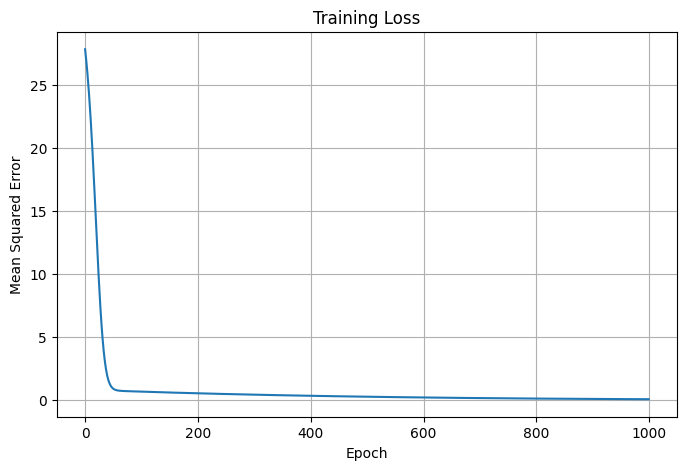

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [ ]:
predictions = []

for j in range(X.shape[0]):
    X_sample = X[j].reshape(-1, 1)

    y_hat, _ = L_layer_forward(
        X_sample,
        trained_parameters
    )

    predictions.append(y_hat.item())

results = df.copy()
results["predicted_lpa"] = np.array(predictions)

results["error"] = results["lpa"] - results["predicted_lpa"]

results

,cgpa,profile_score,lpa,predicted_lpa,error
0,8,8,4,4.476850,-0.476850
1,7,9,5,5.081133,-0.081133
2,6,10,6,5.685417,0.314583
3,5,12,7,6.864869,0.135131


In [ ]:
final_loss = mse_loss(
    y,
    np.array(predictions).reshape(-1, 1)
)

print("Final MSE:", final_loss)

Final MSE: 0.08779779497017091
